In [43]:
import pandas as pd 
import numpy as np 
import seaborn as sns

## Cargando Tablas 

In [44]:
df_transaction = pd.read_csv("train_transaction.csv")
df_identity = pd.read_csv("train_identity.csv")

* train_transaction.csv -> transacciones
* train_identity.csv -> info usuario 

In [45]:
# Para poder ver todas las columnas 
pd.reset_option('display.max_rows', None)

In [46]:
df_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Observar mi variable objetivo

In [47]:
df_transaction['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

Conclusión\
Mi variable objetivo está muy desbalanceada 

#### Missing values

In [48]:
df_transaction.isnull().mean().sort_values(ascending=False).head(20)

dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V139     0.861237
V162     0.861237
V161     0.861237
V154     0.861237
V138     0.861237
V158     0.861237
V157     0.861237
V163     0.861237
V156     0.861237
V155     0.861237
V149     0.861237
dtype: float64

Dato:\
Tengo muchos valores nulos, y no tengo filas duplicadas

### Variables que diferencia fraude

In [49]:
df_transaction.groupby("isFraud")["TransactionAmt"].mean()

isFraud
0    134.511665
1    149.244779
Name: TransactionAmt, dtype: float64

Conclusión:

0 -> No fraude, el importe medio es de 134\
1 -> Fraude, el importe medio es de 149

Esto no quiere decir que un fraude siempre será mayor siempre, pero en promedio son un poco más altos.

<Axes: xlabel='isFraud', ylabel='TransactionAmt'>

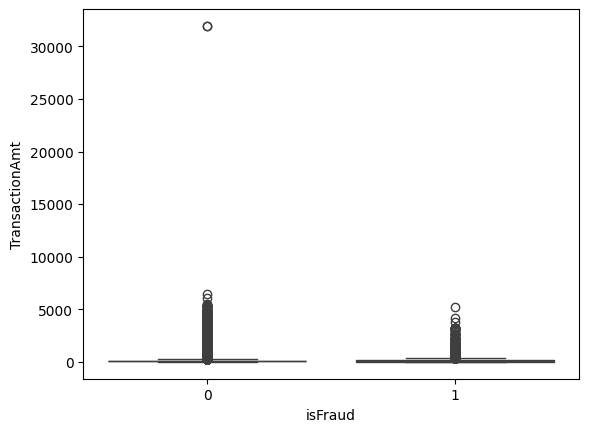

In [50]:
sns.boxplot(x="isFraud", y="TransactionAmt", data=df_transaction)

In [51]:
df_transaction.groupby("isFraud")["TransactionAmt"].describe()


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


Conclusión describe

mediana\
No fraude -> 68\
Fraude -> 75

Percentiles\
No fraude (75%) -> 120\
Fraude (75%) -> 161 

Outliers -> max:\
No fraude -> 31937\
Fraude -> 5191

Fraude no es la transaccion de dinero mas grande, sino lo raro/diferente

### -> Mirando patrones para detectar fraudes

##### Card4 = tipo de tarjeta vs fraude

In [52]:
df_transaction.groupby("card4")['isFraud'].mean()

card4
american express    0.028698
discover            0.077282
mastercard          0.034331
visa                0.034756
Name: isFraud, dtype: float64

Discover tiene MUCHO más fraude -> 7.7% \
el resto entre 3~3.5% -> es más del doble 

Puede ser que haya menos usuarios -> más variabilidad, que tenga diferente comportamiento, 
sesgo del dataset 

In [53]:
# Vamos a observar el volumen de las transacciones de tipo de tarjeta 
df_transaction['card4'].value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

discover tiene muy pocos datos -> 6651 filas y el fraude es de 7.7% fraude\
puede estar inflado, poco estable, no generalizable 


Visa -> N' datos 384767 -> %fraude ~3.5% -> confianza ALTA\
Mastercard -> N' datos 189217 -> %fraude ~3.4% -> confianza ALTA 

In [54]:
df_transaction.groupby("card4")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
card4,,,,,,,,
american express,8328.0,173.057137,162.455160,5.000,100.00,125.000,200.0,1800.000
discover,6651.0,265.750425,402.390329,5.000,57.95,117.000,300.0,4817.580
mastercard,189217.0,132.387731,253.914686,0.272,39.00,62.481,117.0,31937.391
visa,384767.0,133.161806,228.200597,0.251,44.00,68.500,117.0,6450.970


american express -> mediana: 125 -> Transacciones altas -> Outliers 173 -> max: 1800\
discover -> mediana: 117 -> transacciones altas -> Outliers: 265 -> max: 4817 -> mucha variabiliadad (std) 402\
mastercard -> mediana: 62 -> transacciones bajas -> Outliers: 132 -> max: 31937 !!\
visa -> mediana: 68 -> transaccions bajas -> Outliers: 133 -> max: 6450

In [55]:
df_transaction.groupby(["card4", "isFraud"])["TransactionAmt"].mean()

card4             isFraud
american express  0          172.879423
                  1          179.071900
discover          0          258.351905
                  1          354.086459
mastercard        0          132.410999
                  1          131.733248
visa              0          132.577701
                  1          149.383523
Name: TransactionAmt, dtype: float64

<Axes: xlabel='card4', ylabel='TransactionAmt'>

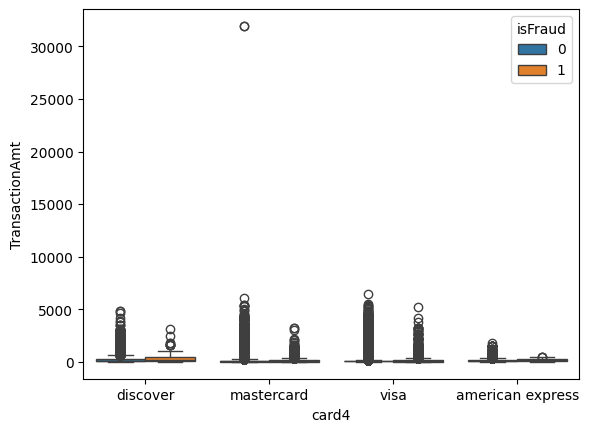

In [56]:
sns.boxplot(x="card4", y="TransactionAmt", hue="isFraud", data=df_transaction)

Las tarjetas American Express y Discover presentan transacciones de mayor importe medio y mediano en comparación con Visa y Mastercard. En particular, Discover muestra una mayor dispersión en los importes, lo que podría estar relacionado con una mayor tasa de fraude observada en este tipo de tarjeta.

#### -> Mirando ProductCD

In [57]:
df_transaction.groupby("ProductCD")['isFraud'].mean()

ProductCD
C    0.116873
H    0.047662
R    0.037826
S    0.058996
W    0.020399
Name: isFraud, dtype: float64

C -> 11.6% de fraude -> este tipo de producto influye MUCHO en el fraude\
resto entre 2% y 6% 

In [58]:
df_transaction['ProductCD'].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

Tamaños de cada grupo\
W -> 439k (Muy grande)\
C -> 68k\
R -> 37k \
H -> 33k\
S -> 11k

Resumen 
W -> muchos datos, poco fraude\
C -> bastantes datos con 68519-> no es poco, MUCHISIMO fraude -> INSIGHT FUERTE Y FIABLE

El tipo de producto C presenta una tasa de fraude significativamente mayor (~11.6%) y cuenta con un volumen considerable de transacciones, lo que lo convierte en un fuerte predictor de fraude.

In [59]:
df_transaction.groupby(["ProductCD", "card4"])["isFraud"].agg(['mean', 'count'])

mean   count
ProductCD card4                             
C         american express  1.000000       2
          mastercard        0.112043   27418
          visa              0.120184   40904
H         american express  0.058110    1566
          discover          0.074627     603
          mastercard        0.052028    7938
          visa              0.044702   22907
R         american express  0.018084    6138
          discover          0.051423    1089
          mastercard        0.050188    7432
          visa              0.038413   23039
S         american express  0.056270     622
          discover          0.132759     580
          mastercard        0.049480    4042
          visa              0.058584    6384
W         discover          0.076730    4379
          mastercard        0.017122  142387
          visa              0.021178  291533

El análisis combinado de ProductCD y card4 revela que el producto C presenta tasas de fraude elevadas (~11–12%) de forma consistente en tarjetas Visa y Mastercard, respaldado por un volumen significativo de transacciones. Esto sugiere que esta combinación es un fuerte indicador de riesgo.

<Axes: xlabel='ProductCD', ylabel='isFraud'>

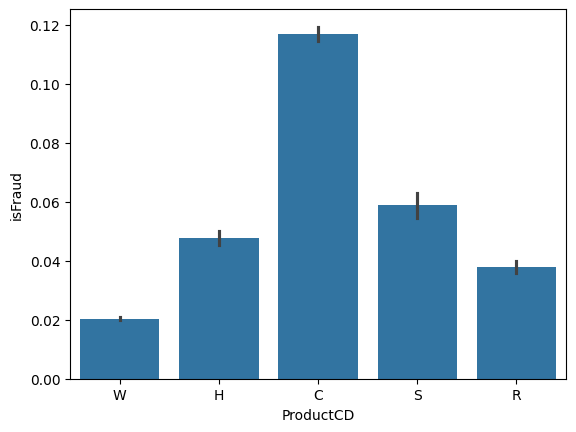

In [60]:
sns.barplot(x="ProductCD", y="isFraud", data=df_transaction)

#### -> Mirando card1 = identificador del cliente

In [61]:
df_transaction['card1'].value_counts()

card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
         ...  
17084        1
14620        1
11440        1
13231        1
18038        1
Name: count, Length: 13553, dtype: int64

Dato:

Esto nos da la frecuencia de uso por tarjeta.

In [62]:
df_transaction.groupby("card1")["isFraud"].mean().sort_values(ascending=False)

card1
10320    1.0
14671    1.0
8185     1.0
11292    1.0
15042    1.0
        ... 
7230     0.0
7232     0.0
7234     0.0
7236     0.0
18396    0.0
Name: isFraud, Length: 13553, dtype: float64

In [63]:
#vamos a filtrar por volumen 
counts = df_transaction['card1'].value_counts()

fraud_rate = df_transaction.groupby("card1")['isFraud'].mean()

#result es la agrupación creada para sacar la media de fraude por número por tarjeta
result = pd.concat([fraud_rate, counts], axis=1)
result.columns = ["fraud_rate", "count"]

result[result["count"] > 100].sort_values("fraud_rate", ascending=False)

,fraud_rate,count
card1,,
3643,0.520661,121
17999,0.485149,101
2939,0.445714,175
2801,0.379562,411
3702,0.345865,133
...,...,...
14661,0.000000,155
7703,0.000000,130
14741,0.000000,207


ALgunas tarjetas (card1) tienen tasas de fraude MUY altas (40-50%) con suficiente volumnen > 100

Se identificaron tarjetas con tasas de fraude significativamente superiores al promedio, lo que sugiere que el comportamiento histórico asociado a identificadores de tarjeta es un fuerte indicador de riesgo.

In [64]:
freq = df_transaction['card1'].value_counts()
df_transaction['card1_freq'] = df_transaction['card1'].map(freq)
freq

card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
         ...  
17084        1
14620        1
11440        1
13231        1
18038        1
Name: count, Length: 13553, dtype: int64

La variable card1 captura comportamiento del usuario y muestra que algunas tarjetas están altamente asociadas a fraude, mientras que otras presentan comportamiento completamente limpio. Esto la convierte en una variable clave para el modelo.

### Eliminando columnas que tengan mas 90% de Nan

In [65]:
threshold = 0.8
df_transaction = df_transaction.loc[:, df_transaction.isnull().mean() < threshold]

In [66]:
df_transaction

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V313,V314,V315,V316,V317,V318,V319,V320,V321,card1_freq
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,0.000000,0.000000,0.000000,0.0,117.0,0.0,0.000000,0.000000,0.000000,43
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,683
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1108
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,0.000000,0.000000,0.000000,50.0,1404.0,790.0,0.000000,0.000000,0.000000,4209
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,47.950001,47.950001,47.950001,0.0,0.0,0.0,0.000000,0.000000,0.000000,1183
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,12
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,690
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,317.500000,669.500000,317.500000,0.0,2234.0,0.0,0.000000,0.000000,0.000000,3006


Tras eliminar columnas con más del 90% de valores nulos, se observa que la mayoría de variables aún contienen valores missing, por lo que será necesario aplicar técnicas de imputación antes del modelado.

In [67]:
df_transaction = df_transaction.copy()

In [68]:
# Como es un dataset de fraude -> se usara randomforest, xgbosst o lightboost
# por eso hare la siguiente sustitución

df_transaction.loc[:, 'TransactionAmt_missing'] = df_transaction['TransactionAmt'].isnull().astype(int)
df_transaction.loc[:, 'TransactionAmt'] = df_transaction['TransactionAmt'].fillna(-999)

## Merge entre transactions y identity 

In [69]:
# Merge
df = df_transaction.merge(df_identity, on="TransactionID", how="left")

In [70]:
# Feature 
df['card1_freq'] = df['card1'].map(df['card1'].value_counts())

# Feature del insight
df['is_C'] = (df['ProductCD'] == 'C').astype(int)

# comportamiento de gasto
df['card1_mean_amt'] = df.groupby('card1')['TransactionAmt'].transform('mean')

# log (reduce outliers)
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'].clip(lower=0))


# hora (patrón temporal)
df['Transaction_hour'] = (df['TransactionDT'] // 3600) % 24

In [71]:
#frecuencia temporal (muy potente) -> detecta tarjetas activas (Fraude suele repetir)
df['card1_tx_count'] = df.groupby('card1')['TransactionID'].transform('count')
#Desviacion respecto a comportamiento, detecta transacciones raras para el usuario 
df['amt_diff'] = df['TransactionAmt'] - df['card1_mean_amt']

In [72]:
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_37,id_38,DeviceType,DeviceInfo,is_C,card1_mean_amt,TransactionAmt_log,Transaction_hour,card1_tx_count,amt_diff
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,0,351.931163,4.241327,0,43,-283.431163
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,0,234.292753,3.401197,0,683,-205.292753
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,0,97.015542,4.094345,0,1108,-38.015542
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,0,123.416340,3.931826,0,4209,-73.416340
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,0,96.972222,3.931826,0,18,-46.972222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,0,96.995799,3.912023,23,1183,-47.995799
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,0,242.041667,3.701302,23,12,-202.541667
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,0,119.741362,3.464172,23,690,-88.791362
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,0,122.763623,4.770685,23,3006,-5.763623


In [73]:
df = df.copy()

In [74]:
# eliminar columnas con muchos NaN igual que nates del merge
df = df.loc[:, df.isnull().mean() < 0.8]

In [75]:
# imputamos los valores de Nan como -999 porque usaremos modelos de árboles
df = df.fillna(-999)

In [76]:
df.to_csv("data_clean.csv", index=False)